<a href="https://colab.research.google.com/github/tamaravdd/iese-dsmba/blob/main/notebooks/07_GeoNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Session 7 · Geographic & Network Data
## When the Mean Is in the Ocean

This session is a **preview** of two powerful data types that don't behave like tabular data — and where the arithmetic mean can actively mislead you.


In [ ]:
#Required packages** — run once:
#!pip install networkx folium

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style('whitegrid')

---
## Part I: Geographic Data — Starbucks Global Locations

Starbucks has over 35,000 stores across 80 countries. The company makes explicit location decisions (density in city centres, proximity to transit, white-space market entry.) Their store location database is a window into that strategy.

- Is there a better way to measure the middle?
- Where are the stores clustered?
  - Which country has the highest stores per capita?
  - Which cities are over-served vs. under-served?

You can download the [data here](https://www.kaggle.com/datasets/starbucks/store-locations) or using the link to my github:

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/directory.csv", delimiter=',')
# I checked what the data looked like to select the corect csv delimiter

df.head()
df.info()
print(f'Loaded: {df.shape[0]} rows')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25600 non-null  object 
 1   Store Number    25600 non-null  object 
 2   Store Name      25600 non-null  object 
 3   Ownership Type  25600 non-null  object 
 4   Street Address  25598 non-null  object 
 5   City            25585 non-null  object 
 6   State/Province  25600 non-null  object 
 7   Country         25600 non-null  object 
 8   Postcode        24078 non-null  object 
 9   Phone Number    18739 non-null  object 
 10  Timezone        25600 non-null  object 
 11  Longitude       25599 non-null  float64
 12  Latitude        25599 non-null  float64
dtypes: float64(2), object(11)
memory usage: 2.5+ MB
Loaded: 25600 rows


> ✅ **Sanity check:** You should have ~25,000+ rows and columns including `Country`, `Longitude`, and `Latitude`. If longitude values are outside [-180, 180] or latitude outside [-90, 90], there are encoding errors. Check with `df[['Longitude','Latitude']].describe()`.

In [3]:
df[['Longitude','Latitude']].describe()

,Longitude,Latitude
count,25599.000,25599.000
mean,-27.872,34.793
std,96.844,13.342
min,-159.460,-46.410
25%,-104.665,31.240
50%,-79.350,36.750
75%,100.630,41.570
max,176.920,64.850


In [4]:
# Drop rows with missing coordinates — can't map them
df = df.dropna(subset=['Longitude', 'Latitude'])

print(f'Rows with valid coordinates: {len(df):,}')
print(f'Countries represented: {df["Country"].nunique()}')

Rows with valid coordinates: 25,599
Countries represented: 73


### 1.1 The Spatial Median — A Better "Middle"

The arithmetic centroid minimises the **sum of squared distances** to all stores. But squaring distances gives disproportionate weight to outliers — which is why the centroid ends up in the ocean (pulled toward Asia by China's 5,000+ stores and toward the Americas by the US's 13,000+ stores).

The **spatial median** (geometric median / Weiszfeld point) minimises the **sum of *un*squared distances**. This makes it outlier-resistant — it finds the point that is, on balance, as close as possible to as many stores as possible.

**Weiszfeld's algorithm** (1937) computes it iteratively:

$$
\mathbf{x}^{(t+1)} = \frac{\sum_i \dfrac{\mathbf{x}_i}{d(\mathbf{x}^{(t)}, \mathbf{x}_i)}}{\sum_i \dfrac{1}{d(\mathbf{x}^{(t)}, \mathbf{x}_i)}}
$$

Each point $\mathbf{x}_i$ is averaged in, but weighted by $1/d_i$ — so *closer* stores pull harder. We stop when the estimate moves less than 1 metre per iteration.

In [5]:
# The regular middle
centroid_lon = df['Longitude'].mean()
centroid_lat = df['Latitude'].mean()

# ── Weiszfeld's algorithm for the spatial median ────────────────────────────
coords = df[['Latitude', 'Longitude']].dropna().values.astype(float)


def spatial_median(points, tol=1e-5, max_iter=300):
    """
    Weiszfeld's iteratively reweighted algorithm.
    Returns (lat, lon) of the geometric median.
    tol: convergence threshold in degrees (~1e-5 deg ≈ 1 metre)
    """
    # Start from the arithmetic centroid
    estimate = points.mean(axis=0)

    for iteration in range(max_iter):
        # Euclidean distances from current estimate to all points (in degrees)
        diffs = points - estimate                        # (n, 2)
        dists = np.linalg.norm(diffs, axis=1)            # (n,)

        # Avoid division by zero: if any point *is* the estimate, nudge it
        dists = np.where(dists < 1e-10, 1e-10, dists)

        # Inverse-distance weights
        weights = 1.0 / dists                            # (n,)

        # Weighted average
        new_estimate = np.average(points, weights=weights, axis=0)

        # Check convergence
        shift = np.linalg.norm(new_estimate - estimate)
        estimate = new_estimate

        if shift < tol:
            print(f"Converged after {iteration + 1} iterations (shift = {shift:.2e}°)")
            break
    else:
        print(f"Warning: did not fully converge after {max_iter} iterations")

    return estimate

spatial_med = spatial_median(coords)
sp_lat, sp_lon = spatial_med


print(f"  Arithmetic centroid : ({centroid_lat:+.2f}°N, {centroid_lon:+.2f}°E)  ← mean of lat, mean of lon")
print(f"  Spatial median      : ({sp_lat:+.2f}°N, {sp_lon:+.2f}°E)  ← minimises total distance")
print()

# Distance between the two estimates (approximate, in km)
from math import radians, cos, sin, asin, sqrt
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

gap_km = haversine(centroid_lat, centroid_lon, sp_lat, sp_lon)
print(f"  Distance apart      : {gap_km:,.0f} km  (~{gap_km/6371*180/3.14:.1f}° on the globe)")
print()

Converged after 36 iterations (shift = 8.65e-06°)
  Arithmetic centroid : (+34.79°N, -27.87°E)  ← mean of lat, mean of lon
  Spatial median      : (+38.38°N, -77.81°E)  ← minimises total distance

  Distance apart      : 4,422 km  (~39.8° on the globe)



In [6]:
import folium
from folium.plugins import HeatMap

# Comparison map: centroid vs spatial median
m_compare = folium.Map(location=[30, 15], zoom_start=2, tiles='CartoDB dark_matter')

# Heatmap layer
heat_data = df[['Latitude', 'Longitude']].dropna().values.tolist()

# Store density as background
HeatMap(heat_data, radius=8, blur=12, min_opacity=0.25, max_zoom=8).add_to(m_compare)

# Arithmetic centroid — red X
folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup=folium.Popup(
        f'<b>Arithmetic centroid</b><br>'
        f'({centroid_lat:.2f}°N, {centroid_lon:.2f}°E)<br>'
        f'Minimises sum of <i>squared</i> distances<br>'
        f'<span style="color:red">← no stores here!</span>',
        max_width=260
    ),
    icon=folium.Icon(color='red', icon='remove', prefix='fa'),
    tooltip='Arithmetic centroid (mean lat/lon)'
).add_to(m_compare)

# Spatial median — green star
folium.Marker(
    location=[sp_lat, sp_lon],
    popup=folium.Popup(
        f'<b>Spatial median</b><br>'
        f'({sp_lat:.2f}°N, {sp_lon:.2f}°E)<br>'
        f'Minimises sum of <i>absolute</i> distances<br>'
        f'Weiszfeld algorithm, converged iteratively',
        max_width=260
    ),
    icon=folium.Icon(color='green', icon='star', prefix='fa'),
    tooltip='Spatial median (geometric median)'
).add_to(m_compare)

# Draw a line between them to make the gap visible
folium.PolyLine(
    locations=[[centroid_lat, centroid_lon], [sp_lat, sp_lon]],
    color='white', weight=2, dash_array='6 4', opacity=0.7,
    tooltip=f'{gap_km:,.0f} km apart'
).add_to(m_compare)

folium.LayerControl().add_to(m_compare)

display(m_compare)
print(f"The two markers are {gap_km:,.0f} km apart — the spatial median wins by staying on land.")

The two markers are 4,422 km apart — the spatial median wins by staying on land.


### 1.2 Density and Market Penetration

Where are the clusters? (density) Where are customers underserved?

First, we will look at the raw number of stores by country.

#### Raw counts by country

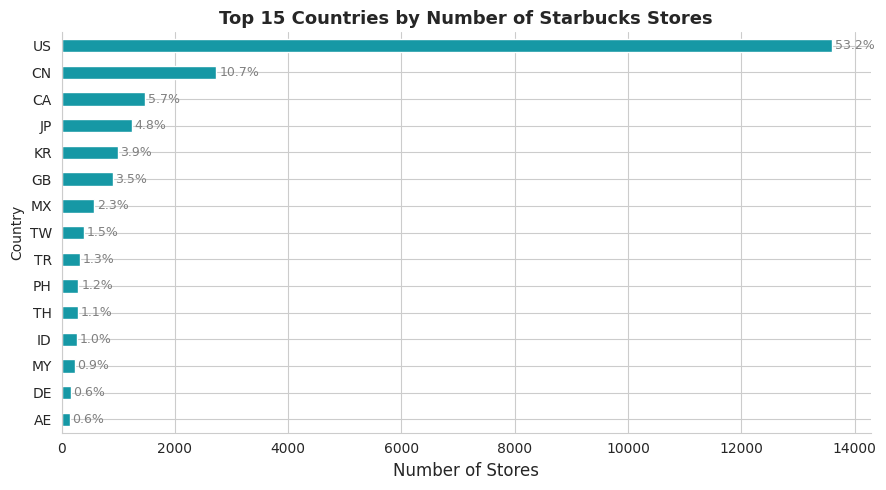

US share: 53.2%


In [ ]:
# Stores per country — top 15
top_countries = df['Country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_countries[::-1].plot.barh(ax=ax, color='#1698A5', edgecolor='white')
ax.set_xlabel('Number of Stores', fontsize=12)
ax.set_title('Top 15 Countries by Number of Starbucks Stores', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# Annotate with % of total
total = len(df)
for i, (country, count) in enumerate(top_countries[::-1].items()):
    ax.text(count + 50, i, f'{count/total:.1%}', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()
print(f'US share: {df["Country"].value_counts()["US"]/total:.1%}')

In [7]:
df

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,47370-257954,"Meritxell, 96",Licensed,"Av. Meritxell, 96",Andorra la Vella,7,AD,AD500,376818720,GMT+1:00 Europe/Andorra,1.530,42.510
1,Starbucks,22331-212325,Ajman Drive Thru,Licensed,"1 Street 69, Al Jarf",Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.470,25.420
2,Starbucks,47089-256771,Dana Mall,Licensed,Sheikh Khalifa Bin Zayed St.,Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.470,25.390
3,Starbucks,22126-218024,Twofour 54,Licensed,Al Salam Street,Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.380,24.480
4,Starbucks,17127-178586,Al Ain Tower,Licensed,"Khaldiya Area, Abu Dhabi Island",Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.540,24.510
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25595,Starbucks,21401-212072,Rex,Licensed,"141 Nguyễn Huệ, Quận 1, Góc đường Pasteur và L...",Thành Phố Hồ Chí Minh,SG,VN,70000,08 3824 4668,GMT+000000 Asia/Saigon,106.700,10.780
25596,Starbucks,24010-226985,Panorama,Licensed,"SN-44, Tòa Nhà Panorama, 208 Trần Văn Trà, Quận 7",Thành Phố Hồ Chí Minh,SG,VN,70000,08 5413 8292,GMT+000000 Asia/Saigon,106.710,10.720
25597,Starbucks,47608-253804,Rosebank Mall,Licensed,"Cnr Tyrwhitt and Cradock Avenue, Rosebank",Johannesburg,GT,ZA,2194,27873500159,GMT+000000 Africa/Johannesburg,28.040,-26.150
25598,Starbucks,47640-253809,Menlyn Maine,Licensed,"Shop 61B, Central Square, Cnr Aramist & Coroba...",Menlyn,GT,ZA,181,NaN,GMT+000000 Africa/Johannesburg,28.280,-25.790


#### Per Capita

This does not help us that much because some of these countries are much smaller than others. A better approach is to look at stores per capita.

For this, we need population by country. I got a dataset with country codes and population in 2025 [on kaggle](https://www.kaggle.com/datasets/thebreaker49/world-population). You can downloaded from the github here:

In [8]:
pop_raw = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/WorldPopulationByCountry.csv", delimiter=',')

pop_raw.head()
pop_raw.info()
print(f'Loaded: {pop_raw.shape[0]} rows')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pop2025          234 non-null    int64  
 1   pop2050          234 non-null    int64  
 2   country          234 non-null    object 
 3   area             234 non-null    float64
 4   landAreaKm       234 non-null    float64
 5   cca2             233 non-null    object 
 6   cca3             234 non-null    object 
 7   density          234 non-null    float64
 8   growthRate       234 non-null    float64
 9   worldPercentage  234 non-null    float64
 10  rank             234 non-null    int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 20.2+ KB
Loaded: 234 rows


In [9]:
pop_raw

,pop2025,pop2050,country,area,landAreaKm,cca2,cca3,density,growthRate,worldPercentage,rank
0,1463870000,1679590000,India,3287590.000,2973190.000,IN,IND,492.357,0.009,0.183,1
1,1416100000,1260290000,China,9706961.000,9424702.900,CN,CHN,150.254,-0.002,0.177,2
2,347276000,380847000,United States,9372610.000,9147420.000,US,USA,37.964,0.005,0.043,3
3,285721000,320713000,Indonesia,1904569.000,1877519.000,ID,IDN,152.180,0.008,0.036,4
4,255220000,371864000,Pakistan,881912.000,770880.000,PK,PAK,331.076,0.016,0.032,5
...,...,...,...,...,...,...,...,...,...,...,...
229,4359,3692,Montserrat,102.000,102.000,MS,MSR,42.735,-0.007,0.000,230
230,3469,3176,Falkland Islands,12173.000,12173.000,FK,FLK,0.285,-0.000,0.000,231
231,2608,3821,Tokelau,12.000,10.000,TK,TKL,260.800,0.041,0.000,232
232,1821,1966,Niue,261.000,261.000,NU,NIU,6.977,0.001,0.000,233


Let's create a per country strabucks data

In [10]:
country_counts = df['Country'].value_counts().reset_index()
# value_counts() counts how many rows have each country code and returns a Series sorted descending.
country_counts.columns = ['Country', 'store_count']
country_counts

,Country,store_count
0,US,13608
1,CN,2734
2,CA,1468
3,JP,1237
4,KR,992
...,...,...
68,SK,3
69,ZA,3
70,LU,2
71,MC,2


Now we combine the datasets!

In [11]:
country_density = country_counts.merge(pop_raw, left_on='Country', right_on='cca2', how='left')
# left because I want everything from my Starbucks dataset to be matched
print(country_density['cca2'].isna().sum())   # not matched
print(country_density['cca2'].notna().sum())  # matched
country_density

0
73


,Country,store_count,pop2025,pop2050,country,area,landAreaKm,cca2,cca3,density,growthRate,worldPercentage,rank
0,US,13608,347276000,380847000,United States,9372610.000,9147420.000,US,USA,37.964,0.005,0.043,3
1,CN,2734,1416100000,1260290000,China,9706961.000,9424702.900,CN,CHN,150.254,-0.002,0.177,2
2,CA,1468,40126700,45621900,Canada,9984670.000,8965590.000,CA,CAN,4.476,0.010,0.005,38
3,JP,1237,123103000,105123000,Japan,377930.000,364500.000,JP,JPN,337.731,-0.005,0.015,12
4,KR,992,51667000,45143100,South Korea,100210.000,97600.000,KR,KOR,529.375,-0.001,0.006,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,SK,3,5474880,4936490,Slovakia,49037.000,49035.000,SK,SVK,111.653,-0.006,0.001,123
69,ZA,3,64747300,79177300,South Africa,1221037.000,1213090.000,ZA,ZAF,53.374,0.012,0.008,24
70,LU,2,680453,791464,Luxembourg,2586.000,2574.500,LU,LUX,264.305,0.011,0.000,168
71,MC,2,38341,36757,Monaco,2.020,2.000,MC,MCO,19170.500,-0.007,0.000,218


In [12]:
# Now let's calculate the density!
country_density['stores_per_million'] = (country_density['store_count'] / country_density['pop2025'] * 1_000_000).round(1)
country_density.sort_values('stores_per_million', ascending=False)

,Country,store_count,pop2025,pop2050,country,area,landAreaKm,cca2,cca3,density,growthRate,worldPercentage,rank,stores_per_million
71,MC,2,38341,36757,Monaco,2.020,2.000,MC,MCO,19170.500,-0.007,0.000,218,52.200
0,US,13608,347276000,380847000,United States,9372610.000,9147420.000,US,USA,37.964,0.005,0.043,3,39.200
2,CA,1468,40126700,45621900,Canada,9984670.000,8965590.000,CA,CAN,4.476,0.010,0.005,38,36.600
66,AW,3,108147,100002,Aruba,180.000,180.000,AW,ABW,600.817,0.001,0.000,196,27.700
54,BS,10,403033,424265,Bahamas,13943.000,10010.000,BS,BHS,40.263,0.004,0.000,177,24.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,VN,25,101599000,110009000,Vietnam,331212.000,313429.000,VN,VNM,324.153,0.006,0.013,16,0.200
64,KH,4,17848000,21931500,Cambodia,181035.000,176520.000,KH,KHM,101.110,0.012,0.002,73,0.200
50,CO,11,53425600,59385400,Colombia,1141748.000,1109500.000,CO,COL,48.153,0.010,0.007,28,0.200
25,IN,88,1463870000,1679590000,India,3287590.000,2973190.000,IN,IND,492.357,0.009,0.183,1,0.100


This changes the story a bit, Monaco is actually the place with the most Starbucks per capita (it makes sense given its very small population).

India and South Africa stand out as untapped markets.

How could we plot this?

#### By city

Here is a list of US cities and their population


```
city_population = {
    'New York':      8_336_817,  'Chicago':    2_696_555,  'Las Vegas':    651_319,
    'Seattle':         737_255,  'Houston':    2_304_580,  'San Diego':  1_386_932,
    'Los Angeles':   3_898_747,  'Portland':    652_503,   'Phoenix':    1_608_139,
    'Dallas':        1_304_379,  'San Francisco': 873_965, 'Atlanta':      498_715,
    'Denver':          715_522,  'Boston':       675_647,  'Austin':       961_855,
}
```

>✏️ **You try it**
> - which cities have the highest density of starbucks stores?
> - which cities are underserved?
> - how could we plot this?

*Be careful, city_population is a dictionary and not a dataframe!*

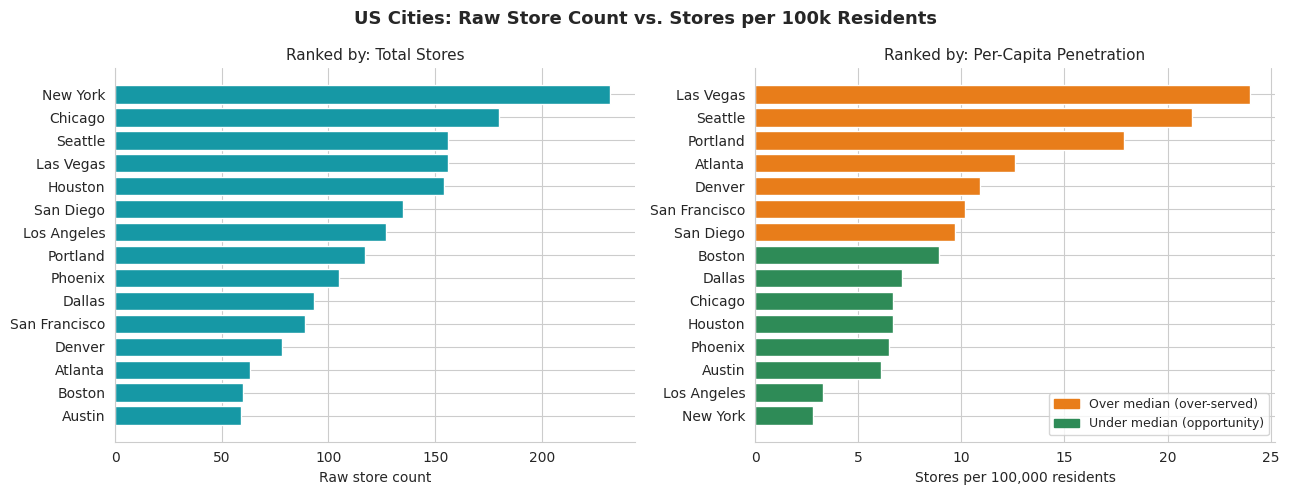

Most over-served (highest stores per 100k):
     City  store_count  stores_per_100k
Las Vegas          156           24.000
  Seattle          156           21.200
 Portland          117           17.900
  Atlanta           63           12.600
   Denver           78           10.900

Most under-served (lowest stores per 100k):
       City  store_count  stores_per_100k
    Houston          154            6.700
    Phoenix          105            6.500
     Austin           59            6.100
Los Angeles          127            3.300
   New York          232            2.800


In [13]:
# Curated population data for top US cities (US Census 2020 estimates)
city_population = {
    'New York':      8_336_817,  'Chicago':    2_696_555,  'Las Vegas':    651_319,
    'Seattle':         737_255,  'Houston':    2_304_580,  'San Diego':  1_386_932,
    'Los Angeles':   3_898_747,  'Portland':    652_503,   'Phoenix':    1_608_139,
    'Dallas':        1_304_379,  'San Francisco': 873_965, 'Atlanta':      498_715,
    'Denver':          715_522,  'Boston':       675_647,  'Austin':       961_855,
}

# select only sities in the US
city_US = df[df['City'].isin(city_population.keys())]

# calculate the count of store per city
city_counts = city_US['City'].value_counts().reset_index()
city_counts
city_counts.columns = ['City', 'store_count']

# City population is a dictionary and not a dataframe! We need to match city to the key
# and it will return the value.
city_counts['population'] = city_counts['City'].map(city_population)

# calculate the store per million
city_counts['stores_per_100k']  = (city_counts['store_count'] / city_counts['population'] * 100_000).round(1)
city_counts = city_counts.dropna().sort_values('stores_per_100k', ascending=False)
city_counts


# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('US Cities: Raw Store Count vs. Stores per 100k Residents', fontweight='bold', fontsize=13)

# Left: raw count (misleading)
ax = axes[0]
raw_sorted = city_counts.sort_values('store_count', ascending=True)
bars = ax.barh(raw_sorted['City'], raw_sorted['store_count'], color='#1698A5', edgecolor='white')
ax.set_xlabel('Raw store count')
ax.set_title('Ranked by: Total Stores', fontsize=11)
ax.spines[['top','right']].set_visible(False)

# Right: per-capita (honest)
ax = axes[1]
per_sorted = city_counts.sort_values('stores_per_100k', ascending=True)
colors = ['#E87D1A' if s > city_counts['stores_per_100k'].median() else '#2E8B57'
          for s in per_sorted['stores_per_100k']]
ax.barh(per_sorted['City'], per_sorted['stores_per_100k'], color=colors, edgecolor='white')
ax.set_xlabel('Stores per 100,000 residents')
ax.set_title('Ranked by: Per-Capita Penetration', fontsize=11)
ax.spines[['top','right']].set_visible(False)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#E87D1A', label='Over median (over-served)'),
    mpatches.Patch(color='#2E8B57', label='Under median (opportunity)')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print("Most over-served (highest stores per 100k):")
print(city_counts[['City','store_count','stores_per_100k']].head(5).to_string(index=False))
print("\nMost under-served (lowest stores per 100k):")
print(city_counts[['City','store_count','stores_per_100k']].tail(5).to_string(index=False))

<details>
<summary>Click to reveal solution</summary>

```

# Curated population data for top US cities (US Census 2020 estimates)
city_population = {
    'New York':      8_336_817,  'Chicago':    2_696_555,  'Las Vegas':    651_319,
    'Seattle':         737_255,  'Houston':    2_304_580,  'San Diego':  1_386_932,
    'Los Angeles':   3_898_747,  'Portland':    652_503,   'Phoenix':    1_608_139,
    'Dallas':        1_304_379,  'San Francisco': 873_965, 'Atlanta':      498_715,
    'Denver':          715_522,  'Boston':       675_647,  'Austin':       961_855,
}

# select only sities in the US
city_US = df[df['City'].isin(city_population.keys())]

# calculate the count of store per city
city_counts = city_US['City'].value_counts().reset_index()
city_counts
city_counts.columns = ['City', 'store_count']

# City population is a dictionary and not a dataframe! We need to match city to the key
# and it will return the value.
city_counts['population'] = city_counts['City'].map(city_population)

# calculate the store per million
city_counts['stores_per_100k']  = (city_counts['store_count'] / city_counts['population'] * 100_000).round(1)
city_counts = city_counts.dropna().sort_values('stores_per_100k', ascending=False)
city_counts


# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('US Cities: Raw Store Count vs. Stores per 100k Residents', fontweight='bold', fontsize=13)

# Left: raw count (misleading)
ax = axes[0]
raw_sorted = city_counts.sort_values('store_count', ascending=True)
bars = ax.barh(raw_sorted['City'], raw_sorted['store_count'], color='#1698A5', edgecolor='white')
ax.set_xlabel('Raw store count')
ax.set_title('Ranked by: Total Stores', fontsize=11)
ax.spines[['top','right']].set_visible(False)

# Right: per-capita (honest)
ax = axes[1]
per_sorted = city_counts.sort_values('stores_per_100k', ascending=True)
colors = ['#E87D1A' if s > city_counts['stores_per_100k'].median() else '#2E8B57'
          for s in per_sorted['stores_per_100k']]
ax.barh(per_sorted['City'], per_sorted['stores_per_100k'], color=colors, edgecolor='white')
ax.set_xlabel('Stores per 100,000 residents')
ax.set_title('Ranked by: Per-Capita Penetration', fontsize=11)
ax.spines[['top','right']].set_visible(False)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#E87D1A', label='Over median (over-served)'),
    mpatches.Patch(color='#2E8B57', label='Under median (opportunity)')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print("Most over-served (highest stores per 100k):")
print(city_counts[['City','store_count','stores_per_100k']].head(5).to_string(index=False))
print("\nMost under-served (lowest stores per 100k):")
print(city_counts[['City','store_count','stores_per_100k']].tail(5).to_string(index=False))

```

</details>

---
## Part II: Network Data — The Enron Email Network

In 2001, Enron collapsed in one of the largest corporate fraud scandals in history. The Federal Energy Regulatory Commission (FERC) released ~500,000 internal emails as evidence. Researchers quickly built the **email communication network** and found that network structure revealed the power dynamics that financial reports had concealed.

**Who were central to the company? Who had the power? Were there groups?**

A network (or *graph*) has two components:
- **Nodes**: entities (here: email addresses / employees)
- **Edges**: relationships (here: email sent from A to B, with a weight = number of emails)

We use the Python library **NetworkX** to build and analyse graphs.

The data is available [here.](https://snap.stanford.edu/data/email-Enron.html) and I show how to download it below.

In [14]:
# Primary: SNAP email-Enron dataset (edge list, ~1.4MB uncompressed)
# Format: two columns (FromNodeId, ToNodeId) with numeric IDs

edges_df = pd.read_csv('https://snap.stanford.edu/data/email-Enron.txt.gz',
                       sep='\t', comment='#',
                        names=['from_id', 'to_id'], compression='infer')

# SNAP uses numeric IDs; build graph directly called "G"
G = nx.from_pandas_edgelist(edges_df, source='from_id', target='to_id',
                            create_using=nx.DiGraph())

print(f'\nGraph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')


Graph: 36,692 nodes, 367,662 edges


> ✅ **Sanity check:** SNAP version: expect ~36,000 nodes and ~500,000 edges. Backup version: ~40 nodes and ~380 edges. If it's 0, the edge list didn't load.

### 2.1 Exploring the Network

In [17]:
G.number_of_nodes()
G.number_of_edges()
nx.density(G)

0.00027309755503535

In [ ]:
# Basic network statistics
print(f'Nodes:              {G.number_of_nodes():,}')
print(f'Edges:              {G.number_of_edges():,}')
print(f'Is directed:        {nx.is_directed(G)}')
print(f'Density:            {nx.density(G):.5f}')
# density is how many of the possible pairs are actually exchanging emails
print(f'  (1.0 = every node connected to every other node)')

Nodes:              36,692
Edges:              367,662
Is directed:        True
Density:            0.00027
  (1.0 = every node connected to every other node)


In [18]:
# Let's take out for each individual their number of connections
# Degree = total connections per node (in + out)
degrees = dict(G.degree())
degree_values = list(degrees.values())
degree_values[:5]

[2, 140, 2, 10, 16]

In [19]:
# now we can use regular numpy to find the statistics
print(f'  Mean:   {np.mean(degree_values):.1f}')
print(f'  Median: {np.median(degree_values):.1f}')
print(f'  Max:    {max(degree_values)}')
print(f'  Min:    {min(degree_values)}')
print(f'\nMean vs median: {np.mean(degree_values)/np.median(degree_values):.1f}x difference — this is the power-law signature')

  Mean:   20.0
  Median: 6.0
  Max:    2766
  Min:    2

Mean vs median: 3.3x difference — this is the power-law signature


### 2.2 The Degree Distribution — Why Mean Misleads

The degree distribution is the single most important property of a network. Real-world networks (the internet, social networks, email) almost always follow a **power law**: most nodes have very few connections, but a small number of hubs have many. This is the opposite of a bell curve.

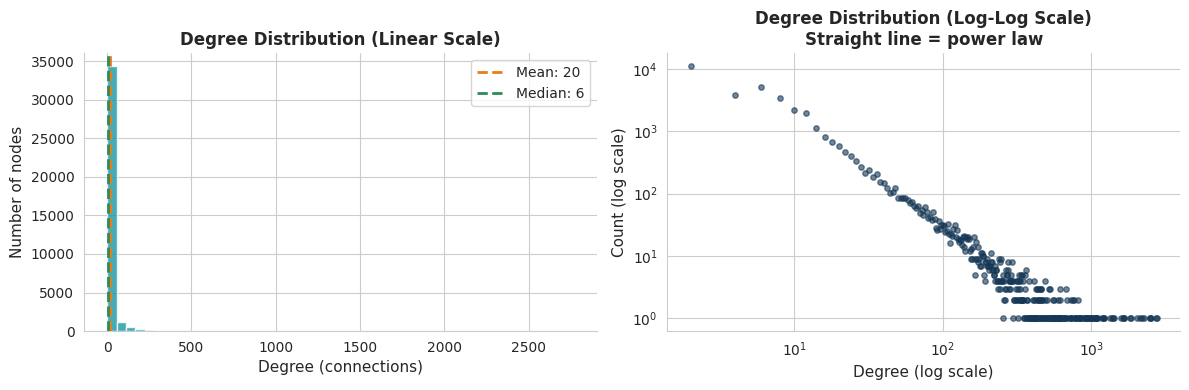

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw histogram
ax = axes[0]
ax.hist(degree_values, bins=50, color='#1698A5', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(degree_values), color='#E87D1A', linestyle='--', linewidth=2, label=f'Mean: {np.mean(degree_values):.0f}')
ax.axvline(np.median(degree_values), color='#2E8B57', linestyle='--', linewidth=2, label=f'Median: {np.median(degree_values):.0f}')
ax.set_xlabel('Degree (connections)', fontsize=11)
ax.set_ylabel('Number of nodes', fontsize=11)
ax.set_title('Degree Distribution (Linear Scale)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# Right: log-log scale reveals the power law
ax = axes[1]
degree_counts = pd.Series(degree_values).value_counts().sort_index()
ax.scatter(degree_counts.index, degree_counts.values,
           s=15, alpha=0.6, color='#163856')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree (log scale)', fontsize=11)
ax.set_ylabel('Count (log scale)', fontsize=11)
ax.set_title('Degree Distribution (Log-Log Scale)\nStraight line = power law', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# What % of nodes have below-average degree?
#below_mean = sum(1 for d in degree_values if d < np.mean(degree_values)) / len(degree_values)
#print(f'{below_mean:.1%} of nodes have BELOW the mean degree — so "average" describes almost nobody')

> ✅ **Sanity check:** On the log-log plot, you should see a roughly straight downward line (the power law signature). The left histogram should be highly right-skewed — a huge spike near 0 and a long tail. If the distribution looks like a bell curve, something unusual is going on with the dataset.

### 2.3 Centrality — Who Really Held Power?

Degree tells us *how many* connections a node has. But there are richer measures of importance:

- *Betweenness* measures how often a node is a bridge on the shortest path between two other notes. In other words, the person who connects otherwise disconnected groups.
- *Closeness* measures how quickly a node can reach everyone else in the network, or the most efficient information spreader.

This data takes a while to run, so I saved it to github. But calculating the nx.betweenness_centrality and nx.degree_centraility is key!



```
# Use undirected version for betweenness (expensive on large directed graphs)
G_und = G.to_undirected()

# finding the largest islands to select the most connected nodes
largest_cc = max(nx.connected_components(G_und), key=len)
G_sub = G_und.subgraph(largest_cc)
print(f'Working on largest component: {G_sub.number_of_nodes():,} nodes')

# Calculate centrality just on that sample
betweenness = nx.betweenness_centrality(G_sub, k=500, seed=42)  # k=sample size
degree_cent = nx.degree_centrality(G_sub)

```



In [20]:
# In case it takes too long to run: let's download these results form my github
# the pickle package enables us to save and retrieve little things
import pickle, urllib.request

url = 'https://raw.githubusercontent.com/tamaravdd/iese-dsmba/27f4e2e16407fd9f371e93bdd62749ea5d619262/resources/centrality_results.pkl'

with urllib.request.urlopen(url) as f:
    results = pickle.load(f)

betweenness = results['betweenness']
degree_cent = results['degree_cent']

In [21]:
print('Top 10 by BETWEENNESS centrality (most "bridging" nodes):')
top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
for node, score in top_between:
    print(f'  {str(node):40s}  betweenness: {score:.4f}')

print('Top 10 by DEGREE centrality (most "connected" nodes):')
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
for node, score in top_degree:
    print(f'  {str(node):40s}  degree: {score:.4f}')

Top 10 by BETWEENNESS centrality (most "bridging" nodes):
  5038                                      betweenness: 0.0838
  140                                       betweenness: 0.0601
  566                                       betweenness: 0.0492
  823                                       betweenness: 0.0439
  1139                                      betweenness: 0.0422
  46                                        betweenness: 0.0402
  588                                       betweenness: 0.0388
  458                                       betweenness: 0.0357
  273                                       betweenness: 0.0331
  195                                       betweenness: 0.0320
Top 10 by DEGREE centrality (most "connected" nodes):
  5038                                      degree: 0.0410
  273                                       degree: 0.0406
  458                                       degree: 0.0374
  140                                       degree: 0.0369
  1028      

> 🧠 **Pause and Think:** A node with high betweenness but low degree is a **broker** — they bridge clusters that don't talk to each other. In the Enron context, what kind of person might that be? (Think: someone in compliance, legal, or a cross-functional coordinator.) Why would that person be interesting to prosecutors?

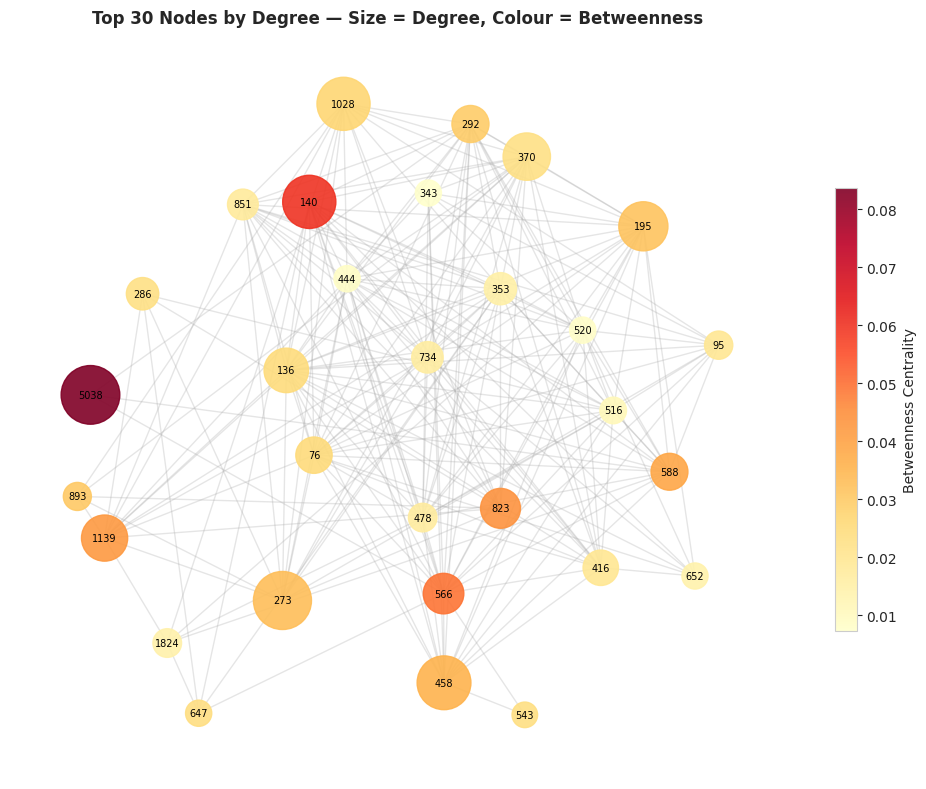

In [23]:
# Visualise a subgraph of the most central nodes
# Take top 30 nodes by degree for a readable plot
G_und = G.to_undirected()
largest_cc = max(nx.connected_components(G_und), key=len)
G_sub = G_und.subgraph(largest_cc)

top_30_nodes = [n for n, _ in sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:30]]
G_viz = G_sub.subgraph(top_30_nodes)

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

pos = nx.spring_layout(G_viz, seed=42, k=2.5)

# Square the centrality to exaggerate size differences
node_sizes = [degree_cent.get(n, 0.01)**2 * 1000000 + 100 for n in G_viz.nodes()]
node_colors = [betweenness.get(n, 0) for n in G_viz.nodes()]

nodes = nx.draw_networkx_nodes(G_viz, pos, node_size=node_sizes,
                                node_color=node_colors, cmap=plt.cm.YlOrRd,
                                alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_viz, pos, alpha=0.3, edge_color='#AAAAAA',
                       arrows=False, ax=ax)
nx.draw_networkx_labels(G_viz, pos, font_size=7, font_color='black', ax=ax)

plt.colorbar(nodes, ax=ax, label='Betweenness Centrality', shrink=0.6)
ax.set_title('Top 30 Nodes by Degree — Size = Degree, Colour = Betweenness',
             fontsize=12, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

> ✅ **Sanity check:** The largest nodes should correspond to the top-degree names printed above. If the graph looks like a single blob with no structure, try adjusting `k` in `spring_layout` (larger k = more spread out). If all nodes are the same size, check that `node_sizes` is using actual centrality values, not a constant.

In [25]:
# Before you try anything, let's reduce the size of the data
# Keep only nodes that appear at least 50 times as sender or receiver
min_emails = 50
active_nodes = set(
    edges_df['from_id'].value_counts()[lambda x: x >= min_emails].index
) | set(
    edges_df['to_id'].value_counts()[lambda x: x >= min_emails].index
)

edges_sample = edges_df[
    edges_df['from_id'].isin(active_nodes) &
    edges_df['to_id'].isin(active_nodes)
]

G_small = nx.from_pandas_edgelist(edges_sample, source='from_id', target='to_id',
                             create_using=nx.DiGraph())


>✏️ **You try it**
>
> 1. Compute **closeness centrality** (`nx.closeness_centrality(G_sub)`) for the top 30 nodes.
> 2. How does it relate to the other measures of centrality?
> 3. Which measure of centrality represent power in this context?

<details>
<summary>Click to reveal solution</summary>

```
# 1. Calculate closeness

closeness = nx.closeness_centrality(G_small)
print('Top 10 by DEGREE closeness ("closest" nodes):')
top_close = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
for node, score in top_close:
    print(f'  {str(node):40s}  degree: {score:.4f}')


# 2. Compare all three measures side by side
print(f"\n{'Node':40s}  {'Degree':>8}  {'Betweenness':>12}  {'Closeness':>10}")
for node in top_30_nodes:
    print(f"  {str(node):40s}  {degree_cent[node]:>8.4f}  {betweenness[node]:>12.4f}  {closeness[node]:>10.4f}")


#3. Plot
pythonfig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    centrality_df['Degree'],
    centrality_df['Betweenness'],
    s=centrality_df['Closeness'] * 2000,
    c=centrality_df['Closeness'],
    cmap='YlOrRd', alpha=0.8, edgecolors='gray', linewidths=0.5
)

# Label the interesting outliers only
for _, row in centrality_df.iterrows():
    if row['Degree'] > 0.03 or row['Betweenness'] > 0.06:
        ax.annotate(row['Node'], xy=(row['Degree'], row['Betweenness']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.colorbar(scatter, ax=ax, label='Closeness Centrality', shrink=0.6)
ax.set_xlabel('Degree Centrality')
ax.set_ylabel('Betweenness Centrality')
ax.set_title('Three Centrality Measures — Top 30 Nodes\n(size + colour = closeness)', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

```
</details>

> **Interpretation** This suggests 5038 is a hub that sits at the periphery of the network rather than the centre. It has many connections and bridges different groups, but those groups are themselves not well-connected to the rest of the network (the average path length from 5038 to everyone else is long). However, the fact that we filtered out people with fewer emails, that probably affected the results.

In [ ]:
# f its neighbours all have low degree themselves, that confirms the peripheral hub interpretation:
neighbors_5038 = list(G_sub.neighbors(5038))
avg_neighbor_degree = np.mean([degree_cent[n] for n in neighbors_5038])
print(f'Node 5038 degree:            {degree_cent[5038]:.4f}')
print(f'Avg neighbour degree:        {avg_neighbor_degree:.4f}')
print(f'Global avg degree:           {np.mean(list(degree_cent.values())):.4f}')

Node 5038 degree:            0.0410
Avg neighbour degree:        0.0001
Global avg degree:           0.0003


### 2.4 Paths

Beyond the nodes themselves, it is interesting to investigate how connected people generally are, one way of looking at this is looking at paths.

In [27]:
# shortest path
path = nx.shortest_path(G_sub, source=top_30_nodes[0], target=top_30_nodes[-1])
print(f'\nShortest path from {top_30_nodes[0]} to {top_30_nodes[-1]}:')
print(f'  {path}')
print(f'  {len(path) - 1} hops')

# average path - takes a while
# avg_path = nx.average_shortest_path_length(G_sub, source=top_30_nodes[0], target=top_30_nodes[-1])
#print(f'Average shortest path length: {avg_path:.4f}')


Shortest path from 5038 to 543:
  [5038, 46, 543]
  2 hops


### 2.5 Community detection

Let's use the Louvain methods to detect some communities.

In [ ]:
# run once
#!pip install python-louvain -q

In [28]:
# Setting up the Louvain method
import community as louvain

partition = louvain.best_partition(G_sub.to_undirected(), random_state=42)
# partition is already a {node: community_id} dict, so replace community_map with it
community_map = partition

In [29]:
# how many communities do we
n_communities = len(set(community_map.values()))
n_communities

183

Very high, maybe not really useful for this dataset

---
## Extra Datasets

You can find a list of networks datasets at the following:

- https://snap.stanford.edu/index.html
- https://icon.colorado.edu/networks
